# Разработка модели поведенческого скоринга клиентов, предсказывающего просрочки 90+ дней на горизонте 12 месяцев

## Подготовка рабочего пространства

### Постановка задачи

Необходимо разработать модель поведенческого скоринга, которая прогнозирует вероятность возникновения просрочки по кредиту длительностью 90+ дней у действующего клиента банка на горизонте 12 месяцев.

Модель должна использовать исторические данные о клиенте и его финансовом поведении, чтобы заранее выявлять риск дефолта и помогать банку управлять ликвидностью и кредитным портфелем.

### Описание данных 

Целевая переменная: бинарная (1— если в течение следующих 12 месяцев возникнет просрочка ≥ 90 дней, 0 — если не возникнет)

Вводные данные: используются несколько таблиц

1. Просрочки: длительность просрочки в днях
2. Транзакции (MCC): расходы по категориям (еда, супермаркеты, ЖКХ, техника и т.д.)
3. Соц-дем профиль: возраст, семейное положение, иждивенцы
4. Кредит: доход, сумма кредита
5. Ипотека: наличие ипотеки
6. Кредитный рейтинг: динамика рейтинга клиента
7. Макроэкономика: инфляция, безработица, ставка ЦБ
8. Дата скоринга

## Перевод бизнес-задачи на язык машинного обучения

### Модели

В рамках задачи планируется обучить несколько моделей: Logistic Regression, Random Forest

Каждую из моделей будем обучать используя балансировку классов, и без использования.

Итоговую модель планируется реализовать на основе ансамблевой модели Random Forest со стратегией балансировки классов и подбором гиперпараметров.

### Методы работы с данными

- Объединение данных в единый датасет
- Создание новых признаков
- Работа с временной структурой данных

### Оценки

Планируется провести обучение baseline-моделей с последующей оценкой их качества по бизнес-метрикам, а также дополнительной проверкой по метрикам **Accuracy** и **ROC-AUC**. На следующем этапе будет выполнено обучение ансамблевой модели и подбор её гиперпараметров для достижения наилучшего качества.

Финальная оценка модели должна соответствовать следующим ограничениям:

- **Approval rate** — не менее **65%**;
- **Default rate** — не более **2%**;
- **Missed defaults rate** — не более **4%**.

## Загрузка необходимых библиотек

In [1]:
# Соберем все необходимые зависимости 

requirements = """
alembic==1.18.4
anyio==4.12.1
appnope==0.1.4
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.1.0
attrs==25.4.0
babel==2.17.0
beautifulsoup4==4.14.3
bleach==6.3.0
certifi==2026.1.4
cffi==2.0.0
charset-normalizer==3.4.4
colorlog==6.10.1
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.19
decorator==5.2.1
defusedxml==0.7.1
dill==0.4.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.61.1
fqdn==1.5.1
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.11
ipykernel==7.1.0
ipython==9.9.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.8
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.13.0
jsonpointer==3.0.0
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.0
jupyter-lsp==2.3.0
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==2.17.0
jupyter_server_terminals==0.5.4
jupyterlab==4.5.2
jupyterlab_pygments==0.3.0
jupyterlab_server==2.28.0
jupyterlab_widgets==3.0.16
kiwisolver==1.4.9
lark==1.3.1
Mako==1.3.10
MarkupSafe==3.0.3
matplotlib==3.10.8
matplotlib-inline==0.2.1
mistune==3.2.0
mlxtend==0.24.0
nbclient==0.10.4
nbconvert==7.16.6
nbformat==5.10.4
nest-asyncio==1.6.0
notebook==7.5.2
notebook_shim==0.2.4
numpy==2.4.4
optuna==4.8.0
packaging==25.0
pandas==3.0.0
pandocfilters==1.5.1
parso==0.8.5
pexpect==4.9.0
phik==0.12.5
pillow==12.1.0
platformdirs==4.5.1
prometheus_client==0.24.1
prompt_toolkit==3.0.52
psutil==7.2.1
ptyprocess==0.7.0
pure_eval==0.2.3
pycparser==2.23
Pygments==2.19.2
pyparsing==3.3.2
python-dateutil==2.9.0.post0
python-json-logger==4.0.0
PyYAML==6.0.3
pyzmq==27.1.0
referencing==0.37.0
requests==2.32.5
rfc3339-validator==0.1.4
rfc3986-validator==0.1.1
rfc3987-syntax==1.1.0
rpds-py==0.30.0
scikit-learn==1.8.0
scipy==1.17.0
seaborn==0.13.2
Send2Trash==2.1.0
setuptools==80.9.0
six==1.17.0
soupsieve==2.8.1
SQLAlchemy==2.0.49
stack-data==0.6.3
terminado==0.18.1
threadpoolctl==3.6.0
tinycss2==1.4.0
tornado==6.5.4
tqdm==4.67.3
traitlets==5.14.3
typing_extensions==4.15.0
tzdata==2025.3
uri-template==1.3.0
urllib3==2.6.3
wcwidth==0.2.14
webcolors==25.10.0
webencodings==0.5.1
websocket-client==1.9.0
widgetsnbextension==4.0.15
"""

In [2]:
# Запишем зависимости в requirements.txt

with open("requirements.txt", "w") as f:
    f.write(requirements)

In [3]:
# Установим зависимости

!pip install -r requirements.txt -qqq 

In [4]:
# Зафиксируем константы

RANDOM_STATE = 627
N_FOLDS = 3

In [5]:
# Импортируем все необходимые библиотеки

import ssl
import urllib.request
import os
import math
import io
import joblib
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, brier_score_loss, confusion_matrix, precision_score
from sklearn.ensemble import RandomForestClassifier
from mlxtend.evaluate import GroupTimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

## Загрузка данных

### Функция загрузки

In [6]:
# Напишем функцию для загрузки файла локально или с сервера

def load_data(local_path, server_path):
    try:
        # Сначала пробуем локальный путь
        print(f"Пробуем загрузить из локального пути: {local_path}")
        df = pd.read_csv(local_path)
        print("Данные загружены из локального файла")
        return df
    
    except FileNotFoundError:
        # Если локальный файл не найден, пробуем серверный
        try:
            df = pd.read_csv(server_path)
            print("Данные загружены с сервера")
            return df
        except FileNotFoundError:
            print("Файл не найден ни в локально, ни на сервере")
            return None
        except Exception as e:
            print(f"Ошибка при загрузке с сервера: {e}")
            return None
    
    except Exception as e:
        print(f"Ошибка при загрузке из локального файла: {e}")
        return None

In [7]:
# Подготовим функционал по работе с неподтвержденными сертификатами

try:
    # Создаем небезопасный контекст
    ssl_context = ssl._create_unverified_context()
except AttributeError:
    # Альтернативный метод, если _create_unverified_context не работает
    ssl_context = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

# Создаем opener с нашим контекстом
https_handler = urllib.request.HTTPSHandler(context=ssl_context)
opener = urllib.request.build_opener(https_handler)
urllib.request.install_opener(opener)

### Загрузка данных

In [8]:
# Укажем пути к файлам с данными

# Данные о просрочке платежа

local_loan_payment_credit = '../datasets/ds_15_loan_payment_credit.csv'
server_loan_payment_credit = 'https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv'

# Месячные транзакции клиента

local_transactions = '../datasets/ds_15_transactions.csv'
server_transactions = 'https://code.s3.yandex.net/datasets/ds_15_transactions.csv'

# Описание клиента на момент регистрации в банке

local_client_description = '../datasets/ds_15_client_description.csv'
server_client_description = 'https://code.s3.yandex.net/datasets/ds_15_client_description.csv'

# Описание кредита

local_credit_description = '../datasets/ds_15_credit_description.csv'
server_credit_description = 'https://code.s3.yandex.net/datasets/ds_15_credit_description.csv'

# Данные о наличии ипотеки

local_mortgage_presence = '../datasets/ds_15_mortgage_presence.csv'
server_mortgage_presence = 'https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv'

# Данные о кредитном рейтинге клиента

local_credit_rating = '../datasets/ds_15_credit_rating.csv'
server_credit_rating = 'https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv'

# Данные о макроэкономических показателях России

local_macro_data = '../datasets/ds_15_macro_data.csv'
server_macro_data = 'https://code.s3.yandex.net/datasets/ds_15_macro_data.csv'

# Данные о дате проведения поведенческого скоринга

local_cohort_grid = '../datasets/ds_15_cohort_grid.csv'
server_cohort_grid = 'https://code.s3.yandex.net/datasets/ds_15_cohort_grid.csv'

In [9]:
# Загружаем данные в датасеты

df_loan_payment_credit = load_data(local_loan_payment_credit, server_loan_payment_credit)

df_transactions = load_data(local_transactions, server_transactions)

df_client_description = load_data(local_client_description, server_client_description)

df_credit_description = load_data(local_credit_description, server_credit_description)

df_mortgage_presence = load_data(local_mortgage_presence, server_mortgage_presence)

df_credit_rating = load_data(local_credit_rating, server_credit_rating)

df_macro_data = load_data(local_macro_data, server_macro_data)

df_cohort_grid = load_data(local_cohort_grid, server_cohort_grid)

Пробуем загрузить из локального пути: ../datasets/ds_15_loan_payment_credit.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_15_transactions.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_15_client_description.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_15_credit_description.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_15_mortgage_presence.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_15_credit_rating.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_15_macro_data.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_15_cohort_grid.csv
Данные загружены из локального файла


### Первичный анализ датасетов

#### Данные о просрочке платежа

In [10]:
df_loan_payment_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   5500 non-null   str  
 1   дата_начала_периода  5500 non-null   str  
 2   просрочка_дней       5500 non-null   int64
dtypes: int64(1), str(2)
memory usage: 129.0 KB


In [11]:
df_loan_payment_credit.head()

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


In [12]:
df_loan_payment_credit.duplicated().sum()

np.int64(0)

Вывод: в датасете с данными о просрочке хранится 5500 строк с идентификатором клиента, датой начала просрочки, числом дней просрочки. Пропусков и дубликатов нет

#### Месячные транзакции клиента

In [13]:
df_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  str    
 1   date        577494 non-null  str    
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), str(2)
memory usage: 44.1 MB


In [14]:
df_transactions.head()

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90


In [15]:
df_transactions.duplicated().sum()

np.int64(0)

In [16]:
df_transactions.describe()

,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
count,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000
mean,6177.123479,3507.682295,2993.862550,9263.099506,1128.116742,3604.437043,3682.487182,5414.896895
std,8835.871514,5710.755226,4541.119582,12299.732992,1557.157475,5005.896972,5567.979383,7190.882383
min,162.910000,62.180000,67.060000,286.110000,31.900000,108.400000,81.290000,166.260000
25%,1360.880000,583.480000,611.540000,2139.480000,245.060000,824.942500,700.632500,1250.850000
50%,2659.590000,1233.110000,1224.530000,4115.385000,476.890000,1590.120000,1397.065000,2398.330000
75%,6561.467500,3642.392500,3201.612500,9287.545000,1159.520000,3866.050000,3872.412500,5413.530000
max,86939.400000,55720.690000,47969.570000,101301.950000,14261.490000,54630.190000,52987.530000,60033.550000


Вывод: в датасете с данными о транзакциях хранится 577494 строк с идентификатором клиента, суммами расходов, распределенных по датам и MCC кодам. Пропусков, дубликатов и аномальных данных (например, отрицательных сумм расходов) нет

#### Описание клиента на момент регистрации в банке

In [17]:
df_client_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  13500 non-null  str  
 1   возраст             13500 non-null  int64
 2   семейное_положение  13500 non-null  str  
 3   наличие_иждивенцев  13500 non-null  int64
 4   дата_регистрации    13500 non-null  str  
dtypes: int64(2), str(3)
memory usage: 527.5 KB


In [18]:
df_client_description.head()

,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


In [19]:
df_client_description.duplicated().sum()

np.int64(0)

In [20]:
df_client_description.describe()

,возраст,наличие_иждивенцев
count,13500.000000,13500.000000
mean,41.304815,0.484741
std,15.096673,0.499786
min,18.000000,0.000000
25%,28.000000,0.000000
50%,40.000000,0.000000
75%,54.000000,1.000000
max,69.000000,1.000000


Вывод: в датасете с данными о клиентах хранится 13500 строк с идентификатором клиента, данными по его семейному положению, возрасту, наличию иждевенцев, дате регистрации в Банке. 

Пропусков, дубликатов и аномальных данных (например, отрицательного числа иждивенцев или возраста) нет

#### Описание кредита

In [21]:
df_credit_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID             13500 non-null  str  
 1   доход          13500 non-null  int64
 2   сумма_кредита  13500 non-null  int64
dtypes: int64(2), str(1)
memory usage: 316.5 KB


In [22]:
df_credit_description.head()

,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


In [23]:
df_credit_description.duplicated().sum()

np.int64(0)

In [24]:
df_credit_description.describe()

,доход,сумма_кредита
count,13500.000000,1.350000e+04
mean,79089.268593,1.993383e+06
std,40045.549462,1.061381e+06
min,15010.000000,7.500000e+04
25%,43347.000000,1.079329e+06
50%,77991.500000,2.032732e+06
75%,113615.500000,2.919236e+06
max,149988.000000,3.749400e+06


Вывод: в датасете с данными по кредиту хранится 13500 строк с идентификатором клиента, данными по его доходу и сумме кредита. 

Пропусков, дубликатов и аномальных данных (например, отрицательной суммы кредита) нет

#### Данные о наличии ипотеки

In [25]:
df_mortgage_presence.info()

<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               6609 non-null   str  
 1   дата_открытия    6609 non-null   str  
 2   наличие_ипотеки  6609 non-null   int64
dtypes: int64(1), str(2)
memory usage: 155.0 KB


In [26]:
df_mortgage_presence.head()

,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


In [27]:
df_mortgage_presence.duplicated().sum()

np.int64(0)

In [28]:
df_mortgage_presence.describe()

,наличие_ипотеки
count,6609.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


Вывод: в датасете с данными о наличии ипотеки хранится 6609 строк с идентификатором клиента, датой открытия ипотеки, фактом наличия ипотеки. При этом, поле Наличие_ипотеки выглядит избыточным, так как 100% значений этого поля равны 1.

Дубликатов в данных нет

#### Данные о кредитном рейтинге клиента

In [29]:
df_credit_rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ID                 577494 non-null  str  
 1   date               577494 non-null  str  
 2   кредитный_рейтинг  577494 non-null  int64
dtypes: int64(1), str(2)
memory usage: 13.2 MB


In [30]:
df_credit_rating.head()

,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


In [31]:
df_credit_rating.duplicated().sum()

np.int64(0)

In [32]:
df_credit_rating.describe()

,кредитный_рейтинг
count,577494.000000
mean,603.190961
std,64.358896
min,343.000000
25%,558.000000
50%,600.000000
75%,646.000000
max,900.000000


Вывод: в датасете с данными по кредитному рейтингу хранится 577494 строк с идентификатором клиента, данными по его кредитному рейтингу за определенную дату.

Пропусков, дубликатов и аномальных данных (например, отрицательной рейтинга) нет

#### Данные о макроэкономических показателях России

In [33]:
df_macro_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     str    
 1   учетная_ставка       84 non-null     float64
 2   уровень_безработицы  84 non-null     float64
 3   инфляция             84 non-null     float64
dtypes: float64(3), str(1)
memory usage: 2.8 KB


In [34]:
df_macro_data.head()

,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


In [35]:
df_macro_data.duplicated().sum()

np.int64(0)

In [36]:
df_macro_data.describe()

,учетная_ставка,уровень_безработицы,инфляция
count,84.000000,84.000000,84.000000
mean,8.638517,5.175000,0.527500
std,2.466112,0.409488,0.570189
min,5.500000,4.300000,-0.540000
25%,7.250000,4.900000,0.262500
50%,7.750000,5.200000,0.425000
75%,10.329545,5.500000,0.635000
max,17.000000,6.000000,3.850000


Вывод: в датасете с данными по макроэкономическим показателям хранится 84 строки с данными по безработице, базовой ставке, инфляции за определенную дату

Пропусков, дубликатов и аномальных данных (например, отрицатальной ставки) нет.
В данных по инфляции есть отрицательные значения, но это выглядит нормально - в конкретные месяцы могла быть зафиксирована дефляция.

#### Данные о дате проведения поведенческого скоринга

In [37]:
df_cohort_grid.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ID          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB


In [38]:
df_cohort_grid.head()

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


In [39]:
df_cohort_grid.duplicated().sum()

np.int64(0)

Вывод: в датасете с данными по дате проведения поведенческого скоринга хранится 577494 строк с данными с идентификатором клиента и датой проведения скоринговой проверки

Дубликатов и пропусков в данных нет

**Общий вывод:** данные, разделенные на 8 датасетов, загружены корректно. Во всех датасетах нет аномальных значений, дубликатов и пропусков. Эти данные пригодны для дальнейшего выполнения поставленной задачи

## Исследовательский анализ данных

### Описательная часть

В прошлом разделе было выявлено: в данных нет дубликатов и пропусков, все датасеты корректно заполнены. Также нет аномалий в виде выборосов, не валидных с точки зрения бизнеса значений. 

Для визуализации будем использовать датасеты:

 - информация о транзакциях
 - данные о клиентах
 - данные по кредиту
 - данные по кредитному рейтингу

Данные по следующим датасетам использовать для визуализации не будем:

 - данные по просрочкам  - используется для определения целевой переменной
 - данные по дате поведенческого скоринга - технические данные, дата не даст никакой информации
 - данные о макроэкономических показателях - вспомогательные, мало строк
 - данные по ипотеке - у всех клиентов в таблице есть ипотека, визуализировать дату открытия ипотеки не имеет смысла

### Функция для визуализации

In [40]:
# для визуализации создадим функцию

def plot_data(df, name, cols_per_row=3):
    print(f"\nВизуализация датасета: {name}")
    
    # исключаем ID и даты
    drop_cols = ['ID', 'date', 'score_date']
    
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    num_cols = [col for col in num_cols if col not in drop_cols]
    
    cat_cols = df.select_dtypes(include=['object', 'string']).columns
    cat_cols = [col for col in cat_cols if col not in drop_cols]

    # числовые 
    if num_cols:
        n = len(num_cols)
        rows = math.ceil(n / cols_per_row)
        
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 4 * rows))
        axes = axes.flatten()
        
        for i, col in enumerate(num_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
            axes[i].set_title(col)
        
        # удаляем пустые графики
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
    
        plt.tight_layout()
        plt.show()

    # категориальные
    if cat_cols:
        n = len(cat_cols)
        rows = math.ceil(n / cols_per_row)
        
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 4 * rows))
        axes = axes.flatten()
        
        for i, col in enumerate(cat_cols):
            df[col].value_counts().head(10).plot(kind='bar', ax=axes[i])
            axes[i].set_title(col)
            axes[i].tick_params(axis='x', rotation=45)
        
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        
        plt.tight_layout()
        plt.show()

### Визуализация и обработка


Визуализация датасета: Данные по транзакциям


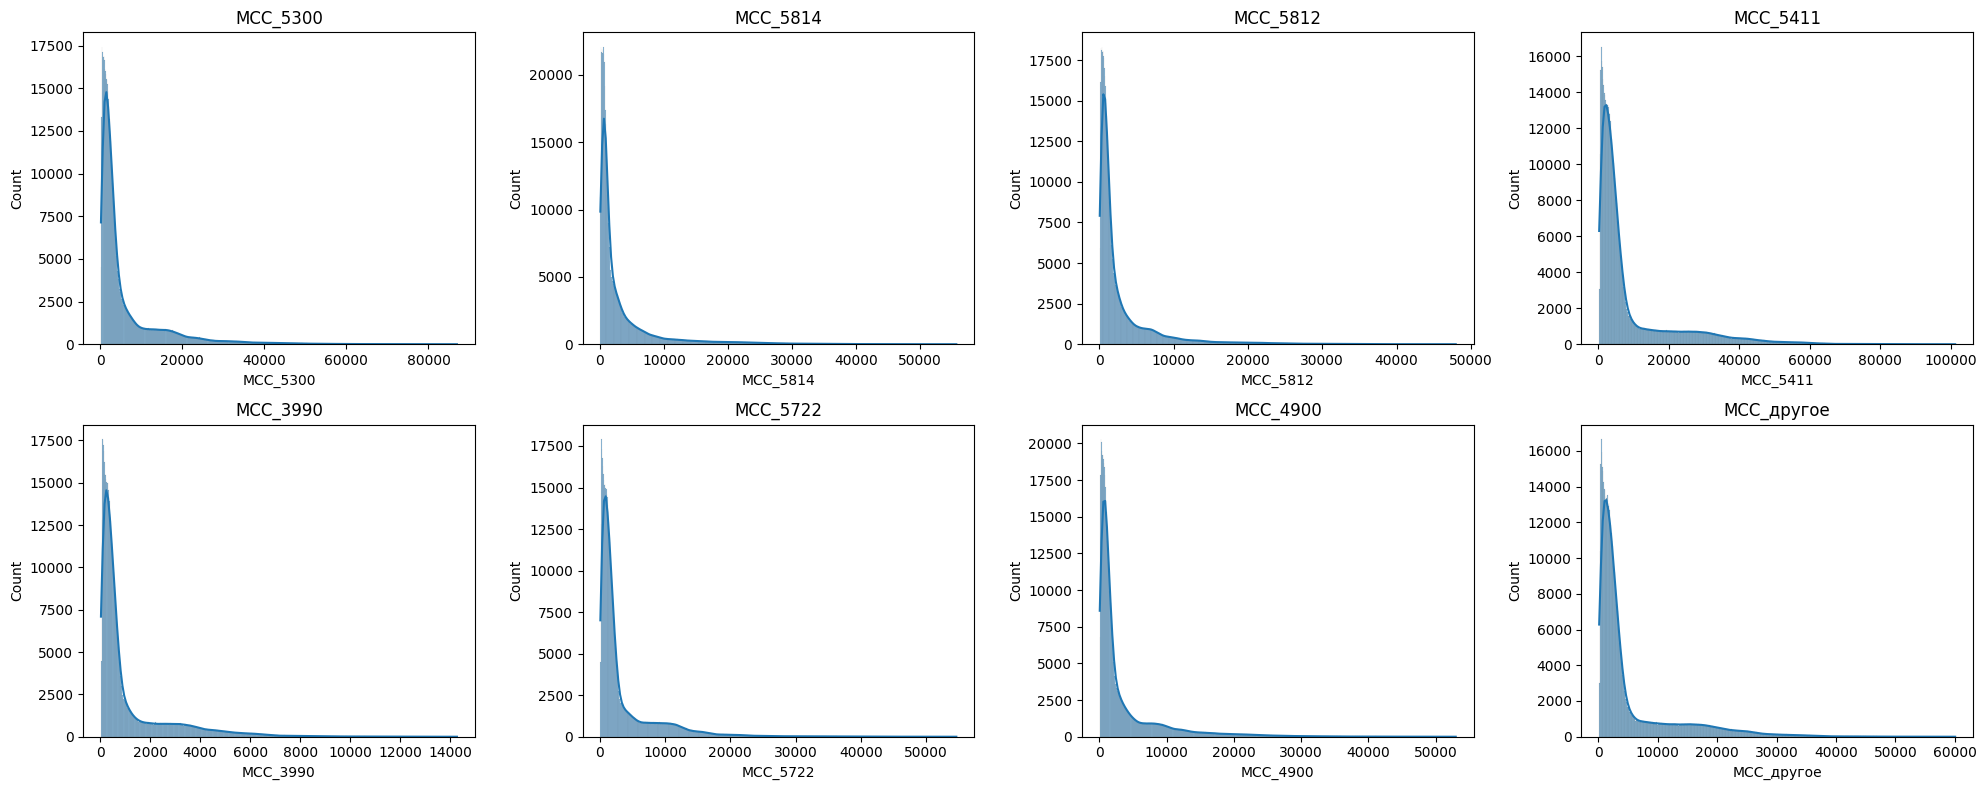

In [41]:
# Выводим распределение по транзакциям

plot_data(df_transactions, "Данные по транзакциям", cols_per_row=4)


Визуализация датасета: Данные по клиентам


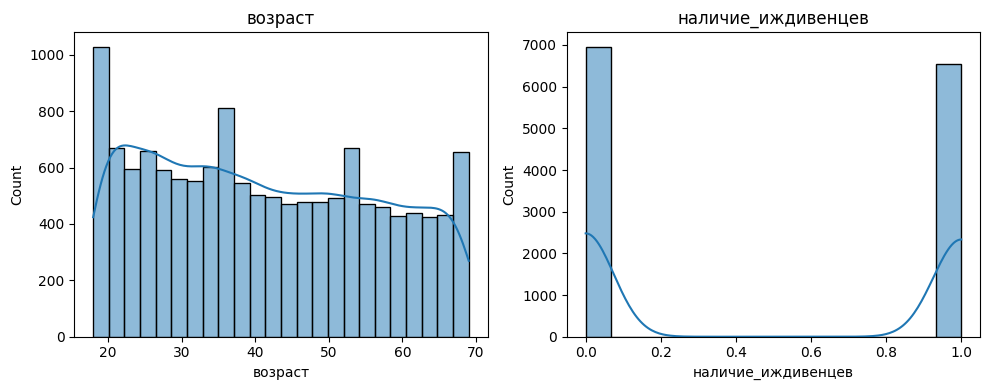

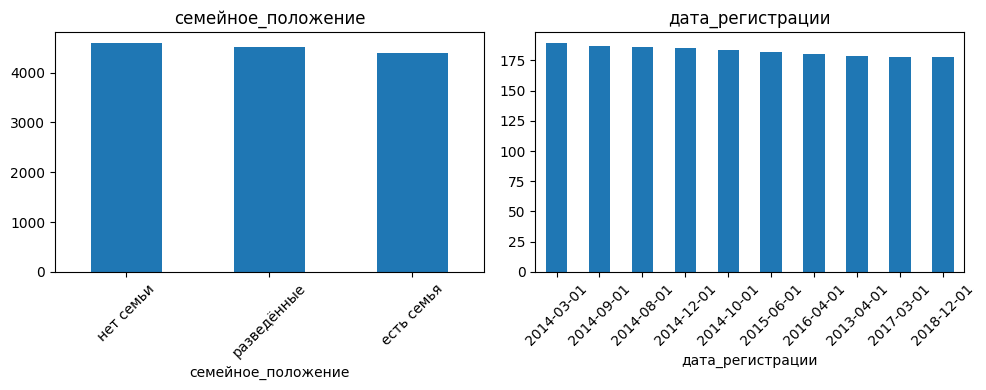

In [42]:
# Выводим распределение данных по клиентам

plot_data(df_client_description, "Данные по клиентам", cols_per_row=2)


Визуализация датасета: Данные по кредитам


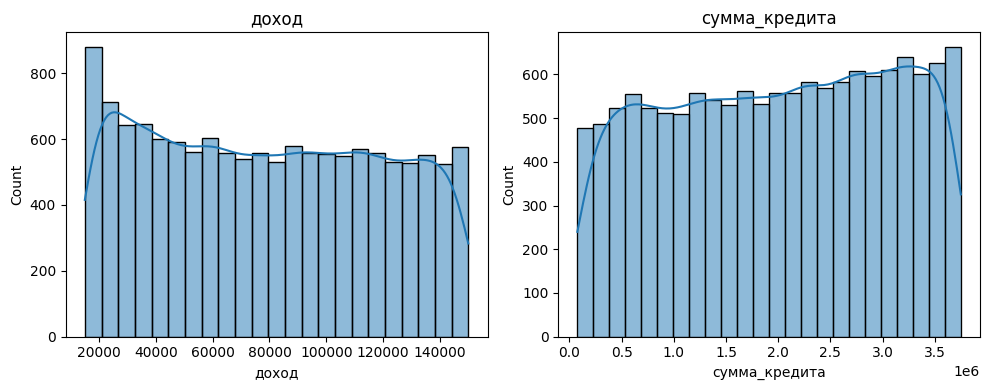

In [43]:
# Выводим распределение информации по кредитам

plot_data(df_credit_description, "Данные по кредитам", cols_per_row=2)


Визуализация датасета: Данные по кредитному рейтингу


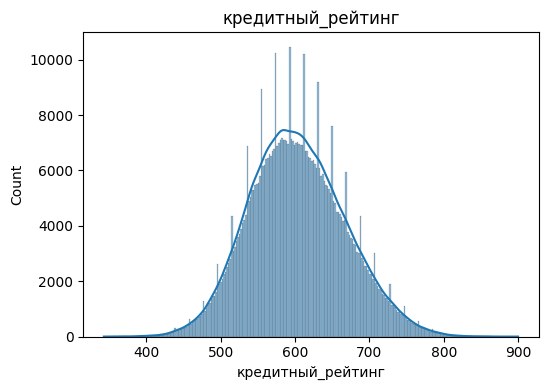

In [44]:
# Выводим распределение информации по кредитному рейтингу

plot_data(df_credit_rating, "Данные по кредитному рейтингу")

In [45]:
# Также необходимо привести даты в формат datetime из строковых значений

df_loan_payment_credit['дата_начала_периода'] = pd.to_datetime(df_loan_payment_credit['дата_начала_периода'])
df_transactions['date'] = pd.to_datetime(df_transactions['date'])
df_client_description['дата_регистрации'] = pd.to_datetime(df_client_description['дата_регистрации'])
df_mortgage_presence['дата_открытия'] = pd.to_datetime(df_mortgage_presence['дата_открытия'])
df_credit_rating['date'] = pd.to_datetime(df_credit_rating['date'])
df_macro_data['date'] = pd.to_datetime(df_macro_data['date'])
df_cohort_grid['score_date'] = pd.to_datetime(df_cohort_grid['score_date'])

In [46]:
# Проверка (выборочно)

df_transactions.info()
df_credit_rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          577494 non-null  str           
 1   date        577494 non-null  datetime64[us]
 2   MCC_5300    577494 non-null  float64       
 3   MCC_5814    577494 non-null  float64       
 4   MCC_5812    577494 non-null  float64       
 5   MCC_5411    577494 non-null  float64       
 6   MCC_3990    577494 non-null  float64       
 7   MCC_5722    577494 non-null  float64       
 8   MCC_4900    577494 non-null  float64       
 9   MCC_другое  577494 non-null  float64       
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 44.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 no

Выводы:

По визуализации видно, что транзакционные признаки (MCC) имеют сильно скошенные распределения с длинным правым хвостом. 
Демографические признаки распределены достаточно равномерно, при этом наличие иждивенцев является бинарным и хорошо сбалансированным признаком.
Доход и сумма кредита распределены достаточно равномерно по диапазону, что говорит о разнообразии клиентской базы, а кредитный рейтинг имеет нормальное распределение с центром около среднего значения.
В целом, данные выглядят реалистично и пригодны для дальнейшего использования

## Объединение таблиц

### Формирование целевой переменной

In [47]:
# делаем копии таблиц
cohort = df_cohort_grid.copy()
loan = df_loan_payment_credit.copy()

# 1. оставляем только эпизоды 90+ дней
loan_90 = loan[loan['просрочка_дней'] >= 90].copy()

# 2. для каждого клиента берём первый дефолт
first_default = (
    loan_90
    .sort_values(['ID', 'дата_начала_периода'])
    .groupby('ID', as_index=False)
    .first()[['ID', 'дата_начала_периода']]
    .rename(columns={'дата_начала_периода': 'first_default_date'})
)

# 3. присоединяем первый дефолт к cohort_grid
df_target = cohort.merge(first_default, on='ID', how='left')

# 4. рассчитываем target
df_target['target'] = (
    df_target['first_default_date'].notna() &
    (df_target['first_default_date'] >= df_target['score_date']) &
    (df_target['first_default_date'] < df_target['score_date'] + pd.Timedelta(days=365))
).astype(int)

# 5. удаляем строки, где дефолт уже был до даты скоринга
df_target = df_target[
    ~(
        df_target['first_default_date'].notna() &
        (df_target['first_default_date'] < df_target['score_date'])
    )
].copy()

df_target.head()

,ID,score_date,first_default_date,target
0,IDF55109846,2013-05-01,2014-12-01,0
1,IDF55109846,2013-06-01,2014-12-01,0
2,IDF55109846,2013-07-01,2014-12-01,0
3,IDF55109846,2013-08-01,2014-12-01,0
4,IDF55109846,2013-09-01,2014-12-01,0


In [48]:
# проверка таблицы

print(df_target.shape)
print(df_target['target'].value_counts(dropna=False))

(438379, 4)
target
0    389015
1     49364
Name: count, dtype: int64


In [49]:
# проверим рандомного клиента вручную

test_id = df_target['ID'].iloc[0]

print("cohort:")
print(df_target[df_target['ID'] == test_id].sort_values('score_date'))

print("\nloan:")
print(
    df_loan_payment_credit[df_loan_payment_credit['ID'] == test_id]
    .sort_values('дата_начала_периода')
)

cohort:
             ID score_date first_default_date  target
0   IDF55109846 2013-05-01         2014-12-01       0
1   IDF55109846 2013-06-01         2014-12-01       0
2   IDF55109846 2013-07-01         2014-12-01       0
3   IDF55109846 2013-08-01         2014-12-01       0
4   IDF55109846 2013-09-01         2014-12-01       0
5   IDF55109846 2013-10-01         2014-12-01       0
6   IDF55109846 2013-11-01         2014-12-01       0
7   IDF55109846 2013-12-01         2014-12-01       0
8   IDF55109846 2014-01-01         2014-12-01       1
9   IDF55109846 2014-02-01         2014-12-01       1
10  IDF55109846 2014-03-01         2014-12-01       1
11  IDF55109846 2014-04-01         2014-12-01       1
12  IDF55109846 2014-05-01         2014-12-01       1
13  IDF55109846 2014-06-01         2014-12-01       1
14  IDF55109846 2014-07-01         2014-12-01       1
15  IDF55109846 2014-08-01         2014-12-01       1
16  IDF55109846 2014-09-01         2014-12-01       1
17  IDF55109846 2014

Вывод: целевая переменная рассчиталась корректно - она нулевая, если до дефолта более года, и получает значение 1 - если до просрочки 90+ дней - более года

### Создание итоговой таблицы

#### Шаг 1. Добавим в таблицу описание клиента и кредита

In [50]:
df_model = df_target.copy()

# Присоединяем описание клиента
df_model = df_model.merge(
    df_client_description,
    on='ID',
    how='left'
)

# Присоединяем описание кредита
df_model = df_model.merge(
    df_credit_description,
    on='ID',
    how='left'
)

print(df_model.shape)
df_model.head()

(438379, 10)


,ID,score_date,first_default_date,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита
0,IDF55109846,2013-05-01,2014-12-01,0,41,разведённые,1,2013-05-01,27035,1960785
1,IDF55109846,2013-06-01,2014-12-01,0,41,разведённые,1,2013-05-01,27035,1960785
2,IDF55109846,2013-07-01,2014-12-01,0,41,разведённые,1,2013-05-01,27035,1960785
3,IDF55109846,2013-08-01,2014-12-01,0,41,разведённые,1,2013-05-01,27035,1960785
4,IDF55109846,2013-09-01,2014-12-01,0,41,разведённые,1,2013-05-01,27035,1960785


#### Шаг 2. Присоединим данные по ипотеке

In [51]:
# Данные по ипотеке надо добавлять с учетом даты скоринга - если ипотека была на дату скоринга, добавляем, если не было - нет

mortgage = df_mortgage_presence.copy()

# важно: сортируем сначала по дате, потом по ID
df_model = df_model.sort_values(['score_date', 'ID']).reset_index(drop=True)
mortgage = mortgage.sort_values(['дата_открытия', 'ID']).reset_index(drop=True)

df_model = pd.merge_asof(
    df_model,
    mortgage,
    left_on='score_date',
    right_on='дата_открытия',
    by='ID',
    direction='backward'
)

df_model['наличие_ипотеки'] = df_model['наличие_ипотеки'].fillna(0)

print(df_model.shape)

(438379, 12)


In [52]:
# Проверка

df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID                  438379 non-null  str           
 1   score_date          438379 non-null  datetime64[us]
 2   first_default_date  62173 non-null   datetime64[us]
 3   target              438379 non-null  int64         
 4   возраст             438379 non-null  int64         
 5   семейное_положение  438379 non-null  str           
 6   наличие_иждивенцев  438379 non-null  int64         
 7   дата_регистрации    438379 non-null  datetime64[us]
 8   доход               438379 non-null  int64         
 9   сумма_кредита       438379 non-null  int64         
 10  дата_открытия       216896 non-null  datetime64[us]
 11  наличие_ипотеки     438379 non-null  float64       
dtypes: datetime64[us](4), float64(1), int64(5), str(2)
memory usage: 40.1 MB


#### Шаг 3. Присоединяем кредитный рейтинг на дату скоринга

In [53]:
rating = df_credit_rating.copy()
rating['date'] = pd.to_datetime(rating['date'])

df_model = df_model.sort_values(['score_date', 'ID'])
rating = rating.sort_values(['date', 'ID'])

df_model = pd.merge_asof(
    df_model,
    rating,
    left_on='score_date',
    right_on='date',
    by='ID',
    direction='backward'
)

print(df_model.shape)

(438379, 14)


In [54]:
# Проверка

df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID                  438379 non-null  str           
 1   score_date          438379 non-null  datetime64[us]
 2   first_default_date  62173 non-null   datetime64[us]
 3   target              438379 non-null  int64         
 4   возраст             438379 non-null  int64         
 5   семейное_положение  438379 non-null  str           
 6   наличие_иждивенцев  438379 non-null  int64         
 7   дата_регистрации    438379 non-null  datetime64[us]
 8   доход               438379 non-null  int64         
 9   сумма_кредита       438379 non-null  int64         
 10  дата_открытия       216896 non-null  datetime64[us]
 11  наличие_ипотеки     438379 non-null  float64       
 12  date                438379 non-null  datetime64[us]
 13  кредитный_рейтинг   438379 non-null  int

#### Шаг 4. Присоединяем данные, которые представлены помесячно

Часть данных (транзакции, макроэкономические показатели) представлены помесячно (то есть в датасете указано 1 число месяца, в котором были совершены транзакции или проведен расчет показателей Банком России). 
Таким образом, эти данные необходимо брать за месяцы, предшествующие месяцу, в котором проводился поведенческий скоринг. Например, скоринг проведен 05-04-2014 - данные за 01-04-2014 брать нельзя, последней возможной датой будет 01-03-2014 - данные за предществующий месяц

In [55]:
# Подготовим границу месяца по датам скоринга

df_model['score_month_start'] = df_model['score_date'].values.astype('datetime64[us]')

# Проверка
df_model['score_month_start'].head(-5)

0        2013-01-01
1        2013-01-01
2        2013-01-01
3        2013-01-01
4        2013-01-01
            ...    
438369   2019-12-01
438370   2019-12-01
438371   2019-12-01
438372   2019-12-01
438373   2019-12-01
Name: score_month_start, Length: 438374, dtype: datetime64[us]

In [56]:
# Присоединим данные по транзакциям за месяц, предшествовавший дате скоринга

transactions = df_transactions.copy()

# только прошлые месяцы, не текущий месяц скоринга
df_model = df_model.sort_values(['score_month_start', 'ID'])
transactions = transactions.sort_values(['date', 'ID'])

df_model = pd.merge_asof(
    df_model,
    transactions,
    left_on='score_month_start',
    right_on='date',
    by='ID',
    direction='backward',
    allow_exact_matches=False
)

In [57]:
# Проверка 

df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID                  438379 non-null  str           
 1   score_date          438379 non-null  datetime64[us]
 2   first_default_date  62173 non-null   datetime64[us]
 3   target              438379 non-null  int64         
 4   возраст             438379 non-null  int64         
 5   семейное_положение  438379 non-null  str           
 6   наличие_иждивенцев  438379 non-null  int64         
 7   дата_регистрации    438379 non-null  datetime64[us]
 8   доход               438379 non-null  int64         
 9   сумма_кредита       438379 non-null  int64         
 10  дата_открытия       216896 non-null  datetime64[us]
 11  наличие_ипотеки     438379 non-null  float64       
 12  date_x              438379 non-null  datetime64[us]
 13  кредитный_рейтинг   438379 non-null  int

In [58]:
# Присоединим данные о макроэкономических показателях по месяцам, предшествующим месяцу скоринга

macro = df_macro_data.copy()
macro['date'] = pd.to_datetime(macro['date'])

# сортировка обязательна для merge_asof
macro = macro.sort_values('date').reset_index(drop=True)

# сортировка df_model
df_model = df_model.sort_values('score_month_start').reset_index(drop=True)

# присоединяем последнее известное макро из прошлого
df_model = pd.merge_asof(
    df_model,
    macro,
    left_on='score_month_start',
    right_on='date',
    direction='backward',
    allow_exact_matches=False
)

In [59]:
# Проверка

df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   438379 non-null  str           
 1   score_date           438379 non-null  datetime64[us]
 2   first_default_date   62173 non-null   datetime64[us]
 3   target               438379 non-null  int64         
 4   возраст              438379 non-null  int64         
 5   семейное_положение   438379 non-null  str           
 6   наличие_иждивенцев   438379 non-null  int64         
 7   дата_регистрации     438379 non-null  datetime64[us]
 8   доход                438379 non-null  int64         
 9   сумма_кредита        438379 non-null  int64         
 10  дата_открытия        216896 non-null  datetime64[us]
 11  наличие_ипотеки      438379 non-null  float64       
 12  date_x               438379 non-null  datetime64[us]
 13  кредитный_рейтинг    4383

In [60]:
# Проверим данные на одном из клиентов

print(df_model.iloc[999])

ID                             IDF55024906
score_date             2013-04-01 00:00:00
first_default_date                     NaT
target                                   0
возраст                                 18
семейное_положение               нет семьи
наличие_иждивенцев                       0
дата_регистрации       2013-03-01 00:00:00
доход                                39231
сумма_кредита                      1579020
дата_открытия          2013-03-01 00:00:00
наличие_ипотеки                        1.0
date_x                 2013-04-01 00:00:00
кредитный_рейтинг                      718
score_month_start      2013-04-01 00:00:00
date_y                 2013-03-01 00:00:00
MCC_5300                            5182.0
MCC_5814                           1930.73
MCC_5812                           2219.95
MCC_5411                           9452.86
MCC_3990                           1010.75
MCC_5722                            3478.0
MCC_4900                            6871.6
MCC_другое 

Далее удаляем последние наблюдения, для которых невозможно корректно рассчитать таргет на горизонте 12 месяцев, так как отсутствуют данные о будущем поведении клиента

In [61]:
# максимальная дата, до которой у нас есть информация о дефолтах
max_date = df_loan_payment_credit['дата_начала_периода'].max()

# фильтрация
df_model = df_model[
    df_model['score_date'] + pd.Timedelta(days=365) <= max_date
].copy()

print(df_model.shape)

(334696, 28)


Удалим технические признаки, которые появились в датасете (дата рейтинга, дата дефолта, дата макроэкономических показателей, дату, до которой требовалось брать скоринги)

In [62]:
# Какие колонки удаляем
cols_to_drop = [
    'first_default_date',
    'date_x',
    'date_y',
    'date',
    'score_month_start'
]

# Удаление

df_model = df_model.drop(columns=cols_to_drop)

# Проверка

df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   334696 non-null  str           
 1   score_date           334696 non-null  datetime64[us]
 2   target               334696 non-null  int64         
 3   возраст              334696 non-null  int64         
 4   семейное_положение   334696 non-null  str           
 5   наличие_иждивенцев   334696 non-null  int64         
 6   дата_регистрации     334696 non-null  datetime64[us]
 7   доход                334696 non-null  int64         
 8   сумма_кредита        334696 non-null  int64         
 9   дата_открытия        164971 non-null  datetime64[us]
 10  наличие_ипотеки      334696 non-null  float64       
 11  кредитный_рейтинг    334696 non-null  int64         
 12  MCC_5300             323083 non-null  float64       
 13  MCC_5814             3230

In [63]:
# Заполним 0 значениями категории, по которым не было трат у клиентов, чтобы убрать пропуски

num_cols = df_model.select_dtypes(include=['float64', 'int64']).columns
df_model[num_cols] = df_model[num_cols].fillna(0)

In [64]:
# Проверка

df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   334696 non-null  str           
 1   score_date           334696 non-null  datetime64[us]
 2   target               334696 non-null  int64         
 3   возраст              334696 non-null  int64         
 4   семейное_положение   334696 non-null  str           
 5   наличие_иждивенцев   334696 non-null  int64         
 6   дата_регистрации     334696 non-null  datetime64[us]
 7   доход                334696 non-null  int64         
 8   сумма_кредита        334696 non-null  int64         
 9   дата_открытия        164971 non-null  datetime64[us]
 10  наличие_ипотеки      334696 non-null  float64       
 11  кредитный_рейтинг    334696 non-null  int64         
 12  MCC_5300             334696 non-null  float64       
 13  MCC_5814             3346

In [65]:
# Также заменим данные по  дата_открытия ипотеки и дата_регистрации клиента в банке 
# на Срок ипотеки на момент скоринга и Срок обслуживания в банке на момент скоринга

# клиент в системе
df_model['client_age_days'] = (
    df_model['score_date'] - df_model['дата_регистрации']
).dt.days

# возраст ипотеки
df_model['mortgage_age_days'] = (
    df_model['score_date'] - df_model['дата_открытия']
).dt.days

# обработка NaN - если ипотеки нет
df_model['mortgage_age_days'] = df_model['mortgage_age_days'].fillna(0)

# Уберем отрицательные значения (если ипотека открыта после скоринга)

df_model['mortgage_age_days'] = df_model['mortgage_age_days'].clip(lower=0)

# Удалим колонки 'дата_регистрации' и 'дата_открытия'

df_model = df_model.drop(columns=['дата_регистрации', 'дата_открытия'])

# Проверка

df_model[['client_age_days', 'mortgage_age_days']].describe()

,client_age_days,mortgage_age_days
count,334696.000000,334696.000000
mean,635.462898,314.986833
std,510.894733,480.575097
min,0.000000,0.000000
25%,213.000000,0.000000
50%,488.000000,0.000000
75%,975.000000,487.000000
max,2160.000000,2160.000000


Вывод: мы получили итоговую таблицу с данными - целевая переменная target, и портрет клиента, сформированный из данных до проведения скоринга (транзакции и др), личных характеристик клиента, данных по продуктам в банке. Далее будем работать с этой таблицей

## Создание новых признаков

Для дальнейшего моделирования соберем несколько новых признаков:

- соотношение отношение суммы кредита к доходу
- сумму обязательных расходов (ЖКХ и еда)
- доля обязательных расходов (ЖКХ и еды) ко всем расходам в месяц

In [66]:
# соберем все данные по тратам

mcc_cols = [
    'MCC_5300', 'MCC_5814', 'MCC_5812',
    'MCC_5411', 'MCC_3990', 'MCC_5722',
    'MCC_4900', 'MCC_другое'
]

# общие траты
df_model['total_spent'] = df_model[mcc_cols].sum(axis=1)

# кредитная нагрузка
df_model['credit_income_ratio'] = df_model['сумма_кредита'] / (df_model['доход'] + 1)

# обязательные расходы
df_model['mandatory_spent'] = (
    df_model['MCC_4900'] +
    df_model['MCC_5411'] +
    df_model['MCC_5812'] +
    df_model['MCC_5814']
)

# доля обязательных расходов
df_model['mandatory_share'] = df_model['mandatory_spent'] / (df_model['total_spent'] + 1)

# защита от выбросов
df_model['mandatory_share'] = df_model['mandatory_share'].clip(0, 1)

In [67]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   334696 non-null  str           
 1   score_date           334696 non-null  datetime64[us]
 2   target               334696 non-null  int64         
 3   возраст              334696 non-null  int64         
 4   семейное_положение   334696 non-null  str           
 5   наличие_иждивенцев   334696 non-null  int64         
 6   доход                334696 non-null  int64         
 7   сумма_кредита        334696 non-null  int64         
 8   наличие_ипотеки      334696 non-null  float64       
 9   кредитный_рейтинг    334696 non-null  int64         
 10  MCC_5300             334696 non-null  float64       
 11  MCC_5814             334696 non-null  float64       
 12  MCC_5812             334696 non-null  float64       
 13  MCC_5411             3346

Новые признаки помогут показать, насколько большой относительно дохода кредит взял пользователь и сколько обязательных трат есть у клиента.
Эти параметры косвенно влияют на возможность клиента обслуживать кредиты и влияют на таргетную переменную по дефолту

## Анализ итоговой таблицы

### Краткая сводка о финальной таблице

In [68]:
# размер и типы
print(df_model.shape)
display(df_model.dtypes)

# пропуски
na = df_model.isna().mean().sort_values(ascending=False)
display(na.head(5))

# базовая статистика по числовым
display(df_model.describe())

# дубликаты
print("Дубликаты (ID, score_date):",
      df_model.duplicated(subset=['ID','score_date']).sum())

(334696, 27)


ID                                str
score_date             datetime64[us]
target                          int64
возраст                         int64
семейное_положение                str
наличие_иждивенцев              int64
доход                           int64
сумма_кредита                   int64
наличие_ипотеки               float64
кредитный_рейтинг               int64
MCC_5300                      float64
MCC_5814                      float64
MCC_5812                      float64
MCC_5411                      float64
MCC_3990                      float64
MCC_5722                      float64
MCC_4900                      float64
MCC_другое                    float64
учетная_ставка                float64
уровень_безработицы           float64
инфляция                      float64
client_age_days                 int64
mortgage_age_days             float64
total_spent                   float64
credit_income_ratio           float64
mandatory_spent               float64
mandatory_sh

ID                     0.0
MCC_3990               0.0
mandatory_spent        0.0
credit_income_ratio    0.0
total_spent            0.0
dtype: float64

,score_date,target,возраст,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,MCC_5300,MCC_5814,...,MCC_другое,учетная_ставка,уровень_безработицы,инфляция,client_age_days,mortgage_age_days,total_spent,credit_income_ratio,mandatory_spent,mandatory_share
count,334696,334696.000000,334696.000000,334696.000000,334696.000000,3.346960e+05,334696.000000,334696.000000,334696.000000,334696.000000,...,334696.000000,334696.000000,334696.000000,334696.000000,334696.000000,334696.000000,334696.000000,334696.000000,334696.000000,334696.000000
mean,2016-10-26 17:57:19.433994,0.132550,42.790090,0.495569,80320.946178,1.941944e+06,0.492898,618.173665,8338.227656,4735.711739,...,7312.435162,9.199483,5.196927,0.481567,635.462898,314.986833,48314.646279,35.376617,26258.196121,0.521586
min,2013-01-01 00:00:00,0.000000,18.000000,0.000000,15010.000000,7.500000e+04,0.000000,367.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-0.540000,0.000000,0.000000,0.000000,0.506236,0.000000,0.000000
25%,2015-10-01 00:00:00,0.000000,29.000000,0.000000,44857.000000,1.022490e+06,0.000000,571.000000,1703.722500,725.047500,...,1577.350000,7.500000,4.900000,0.220000,213.000000,0.000000,10586.360000,12.584429,5575.795000,0.467275
50%,2017-02-01 00:00:00,0.000000,42.000000,0.000000,79938.000000,1.954950e+06,0.000000,618.000000,3790.450000,2037.170000,...,3334.525000,9.000000,5.200000,0.380000,488.000000,0.000000,22163.780000,24.068098,11974.975000,0.559291
75%,2018-02-01 00:00:00,0.000000,56.000000,1.000000,114914.000000,2.862195e+06,1.000000,665.000000,12092.520000,5946.640000,...,11604.717500,10.690476,5.500000,0.590000,975.000000,487.000000,77779.272500,43.459820,42414.665000,0.585241
max,2018-12-01 00:00:00,1.000000,69.000000,1.000000,149981.000000,3.749400e+06,1.000000,900.000000,86939.400000,55720.690000,...,60033.550000,17.000000,6.000000,3.850000,2160.000000,2160.000000,309029.080000,242.954590,175025.730000,0.644811
std,NaN,0.339088,15.176693,0.499981,39817.618785,1.064579e+06,0.499950,67.080946,10228.710075,6558.555730,...,8158.736176,2.175188,0.377419,0.548490,510.894733,480.575097,52972.146346,36.038893,29003.243535,0.113998


Дубликаты (ID, score_date): 0


Датасет содержит 334696 строк, одна строка — клиент в конкретный месяц (score_date).
Признаки разнородные: 
- числовые (доход, сумма кредита, MCC, макро)
- категориальные (семейное положение)
- бинарные (наличие ипотеки/иждивенцев).
    
Пропусков и дубликатов нет.

Числовые признаки имеют разный масштаб - для линейных моделей понадобится масштабирование.

### Дисбаланс целевой переменной

target
0    0.86745
1    0.13255
Name: proportion, dtype: float64


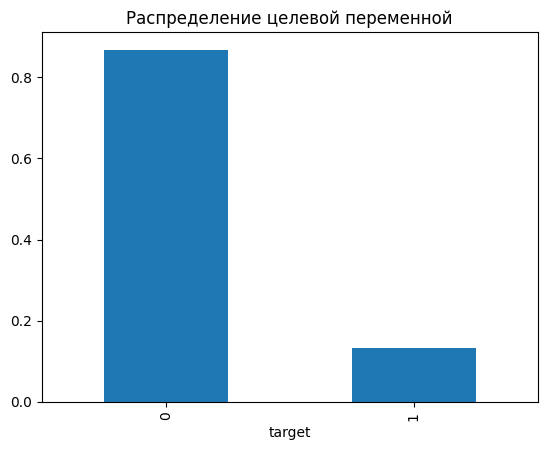

In [69]:
y = df_model['target']

print(y.value_counts(normalize=True))

# визуализация

y.value_counts(normalize=True).plot(kind='bar')
plt.title('Распределение целевой переменной')
plt.show()

Вывод: наблюдается дисбаланс целевой переменной, что требует использования балансировки при обучении и оценке модели.

## Моделирование

### Разделение на выборки

In [70]:
# Отсортируем таблицу по дате скоринга
df_model = df_model.copy()
df_model['score_date'] = pd.to_datetime(df_model['score_date'])
df_model = df_model.sort_values('score_date')

# Максимальная дата скоринга
max_date = df_model['score_date'].max()

# Граница конца теста: первый день месяца, следующего за max_date
test_end = max_date + pd.DateOffset(months=1)

# Тест = последние 12 месяцев
test_start = test_end - pd.DateOffset(months=12)

# Калибровка = предыдущие 12 месяцев
calib_end = test_start
calib_start = calib_end - pd.DateOffset(months=12)

In [71]:
# Делим выборки по датам

train = df_model[df_model['score_date'] < calib_start].copy()

calib = df_model[
    (df_model['score_date'] >= calib_start) &
    (df_model['score_date'] < calib_end)
].copy()

test = df_model[
    (df_model['score_date'] >= test_start) &
    (df_model['score_date'] < test_end)
].copy()


print(f"Обучающая выборка содержит: {train.shape[0]} записей")
print(f"Калибровочная выборка содержит: {calib.shape[0]} записей")
print(f"Тестовая выборка содержит: {test.shape[0]} записей")

print("Месяцев в CALIB:", calib['score_date'].dt.to_period('M').nunique())
print("Месяцев в TEST:", test['score_date'].dt.to_period('M').nunique())

Обучающая выборка содержит: 160953 записей
Калибровочная выборка содержит: 79448 записей
Тестовая выборка содержит: 94295 записей
Месяцев в CALIB: 12
Месяцев в TEST: 12


In [72]:
# Выделяем X и y:

# Соберем колонки для удаления из выборок в список

drop_cols = ['ID', 'target', 'score_date']

# обучающая 
X_train = train.drop(columns=drop_cols)
y_train = train['target']

# калибровочная
X_calib = calib.drop(columns=drop_cols)
y_calib = calib['target']

# тестовая
X_test = test.drop(columns=drop_cols)
y_test = test['target']

In [73]:
# Проверка

print("TRAIN:", train['score_date'].min(), train['score_date'].max())
print("CALIB:", calib['score_date'].min(), calib['score_date'].max())
print("TEST:", test['score_date'].min(), test['score_date'].max())

TRAIN: 2013-01-01 00:00:00 2016-12-01 00:00:00
CALIB: 2017-01-01 00:00:00 2017-12-01 00:00:00
TEST: 2018-01-01 00:00:00 2018-12-01 00:00:00


Вывод: выборки корректно разделены по датам - самые новые данные идут в тестовую выборку, калибровочная и тестовая содержат данные за 12 месяцев. Все остальные данные собраны в обучающий датасет

### Пайплайн и трансформер для обработки данных

In [74]:
# Разобьем группы по месяцам

groups_train = train['score_date'].dt.to_period('M')

# Определим категориальные и числовые признаки

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Размер X_train:', X_train.shape)
print('Размер groups_train:', len(groups_train))
print('Количество уникальных месяцев в train:', groups_train.nunique())

Размер X_train: (160953, 24)
Размер groups_train: 160953
Количество уникальных месяцев в train: 48


In [75]:
# Подготовим препроцессор

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

### Базовые модели и метрики

In [76]:
# Инициализируем 4 модели

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(random_state=RANDOM_STATE),
    "LogReg_balanced": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "RF_balanced": RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
}

In [77]:
# Напишем функцию для сбора бизнес-метрик для оценки

def business_metrics(y_true, y_pred):
    TP = ((y_true == 1) & (y_pred == 1)).sum()
    TN = ((y_true == 0) & (y_pred == 0)).sum()
    FP = ((y_true == 0) & (y_pred == 1)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    
    approval_rate = (TN + FN) / len(y_true)
    default_rate = FN / (FN + TN) if (FN + TN) > 0 else 0
    missed_defaults = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    return approval_rate, default_rate, missed_defaults

### Кросс валидация моделей

In [78]:
# Инициализируем функцию кросс валидации для временных рядов
gts = GroupTimeSeriesSplit(n_splits=N_FOLDS, test_size=12)

cv_results = []

for model_name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    fold_metrics = []

    for fold, (tr_idx, val_idx) in enumerate(
        gts.split(X_train, y_train, groups=groups_train),
        start=1
    ):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        pipe.fit(X_tr, y_tr)

        y_pred = pipe.predict(X_val)
        y_proba = pipe.predict_proba(X_val)[:, 1]

        acc = accuracy_score(y_val, y_pred)
        roc_auc = roc_auc_score(y_val, y_proba)
        approval_rate, default_rate, missed_defaults_rate = business_metrics(y_val, y_pred)

        fold_metrics.append({
            'fold': fold,
            'accuracy': acc,
            'roc_auc': roc_auc,
            'approval_rate': approval_rate,
            'default_rate': default_rate,
            'missed_defaults_rate': missed_defaults_rate
        })

    fold_df = pd.DataFrame(fold_metrics)

    cv_results.append({
        'model': model_name,
        'accuracy_mean': fold_df['accuracy'].mean(),
        'roc_auc_mean': fold_df['roc_auc'].mean(),
        'approval_rate_mean': fold_df['approval_rate'].mean(),
        'default_rate_mean': fold_df['default_rate'].mean(),
        'missed_defaults_rate_mean': fold_df['missed_defaults_rate'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by='missed_defaults_rate_mean',
    ascending=True
)

In [79]:
display(cv_results_df)

,model,accuracy_mean,roc_auc_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
2,LogReg_balanced,0.790639,0.859804,0.729388,0.042784,0.252243
1,RF,0.888056,0.901040,0.944019,0.095138,0.726291
3,RF_balanced,0.885840,0.901406,0.955971,0.101357,0.783566
0,LogReg,0.872582,0.855520,0.969866,0.113902,0.893374


Выводы:

Среди всех базовых моделей только логистическая регрессия с балансировкой продемонстрировала приемлемые значения бизнес-метрик, особенно по показателю missed defaults rate.
Модели без балансировки, а также случайный лес даже с балансировкой, показали высокое качество по ROC-AUC и accuracy, однако оказались неэффективными с точки зрения выявления дефолтов, что делает их непригодными для практического применения в задаче кредитного скоринга.

Таким образом, для дальнейшего улучшения качества модели целесообразно сосредоточиться на настройке более сложных моделей, в частности случайного леса, с использованием подбора гиперпараметров и оптимизацией по бизнес-метрикам.

### Подбор гиперпараметров для случайного леса

In [80]:
# Инициализируем функцию для Optuna

def objective_rf(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 4, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    fold_scores = []

    for tr_idx, val_idx in gts.split(X_train, y_train, groups=groups_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        pipe = Pipeline([
            ('prep', preprocessor),
            ('model', model)
        ])

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)

        _, _, missed_defaults_rate = business_metrics(y_val, y_pred)
        fold_scores.append(missed_defaults_rate)

    return np.mean(fold_scores)

In [99]:
# Запускаем Optuna

study = optuna.create_study(direction='minimize', 
                           sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective_rf, n_trials=20)

# Выводим лучшие параметры и значения
print('Best params:', study.best_params)
print('Best value:', study.best_value)

[I 2026-04-24 17:36:33,694] A new study created in memory with name: no-name-2f9127f4-7ad0-40a5-8af3-ab9a30140465
[I 2026-04-24 17:36:38,316] Trial 0 finished with value: 0.1688810623049156 and parameters: {'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.1688810623049156.
[I 2026-04-24 17:36:42,155] Trial 1 finished with value: 0.11063331143675435 and parameters: {'max_depth': 5, 'min_samples_split': 15, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.11063331143675435.
[I 2026-04-24 17:36:48,655] Trial 2 finished with value: 0.24095005580348508 and parameters: {'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.11063331143675435.
[I 2026-04-24 17:36:56,456] Trial 3 finished with value: 0.34877025817626134 and parameters: {'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.11063331143675435.
[I 2026-04-24 17:37:03,917] Trial 4 finished with value:

Best params: {'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 5}
Best value: 0.07443030339938604


In [100]:
# Модель с лучшими параметрами Optuna
rf_optuna = RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Прогоним модель с подобранными гиперпараметрами через ту же кросс валидацию и добавим метрики для их сравнения

pipe = Pipeline([
    ('prep', preprocessor),
    ('model', rf_optuna)
])

fold_metrics = []

for fold, (tr_idx, val_idx) in enumerate(
    gts.split(X_train, y_train, groups=groups_train),
    start=1
):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    pipe.fit(X_tr, y_tr)

    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)
    approval_rate, default_rate, missed_defaults_rate = business_metrics(y_val, y_pred)

    fold_metrics.append({
        'fold': fold,
        'accuracy': acc,
        'roc_auc': roc_auc,
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate
    })

fold_df_optuna = pd.DataFrame(fold_metrics)

optuna_cv_result = pd.DataFrame([{
    'model': 'RandomForest_Optuna',
    'accuracy_mean': fold_df_optuna['accuracy'].mean(),
    'roc_auc_mean': fold_df_optuna['roc_auc'].mean(),
    'approval_rate_mean': fold_df_optuna['approval_rate'].mean(),
    'default_rate_mean': fold_df_optuna['default_rate'].mean(),
    'missed_defaults_rate_mean': fold_df_optuna['missed_defaults_rate'].mean()
}])

cv_results_with_optuna = pd.concat(
    [cv_results_df, optuna_cv_result],
    ignore_index=True
).sort_values(
    by='missed_defaults_rate_mean',
    ascending=True
)

display(cv_results_with_optuna)

,model,accuracy_mean,roc_auc_mean,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
4,RandomForest_Optuna,0.710227,0.871079,0.605005,0.015238,0.074430
0,LogReg_balanced,0.790639,0.859804,0.729388,0.042784,0.252243
1,RF,0.888056,0.901040,0.944019,0.095138,0.726291
2,RF_balanced,0.885840,0.901406,0.955971,0.101357,0.783566
3,LogReg,0.872582,0.855520,0.969866,0.113902,0.893374


**Вывод:** Результаты кросс-валидации показали, что оптимизированная модель случайного леса, полученная с помощью Optuna, существенно превосходит базовые модели по ключевой бизнес-метрике missed defaults rate, снижая её до 7.4%.


## Калибровка модели и пересчёт результатов

In [101]:
# Сохраним лучшую модель в отдельную переменную и проведем ее обучение на обучающей выборке
best_rf = rf_optuna

# Собираем пайплайн
base_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', best_rf)
])

# Обучаем модель только на обучающей выборке
base_pipe.fit(X_train, y_train)

# Замораживаем уже обученную модель
frozen_model = FrozenEstimator(base_pipe)

In [102]:
# Проведем калибровку замороженной модели

calibrated_model = CalibratedClassifierCV(
    estimator=frozen_model,
    method='isotonic'
)

calibrated_model.fit(X_calib, y_calib)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...state=627))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the c

In [103]:
# Считаем вероятности

# до калибровки
proba_before = base_pipe.predict_proba(X_calib)[:, 1]

# после калибровки
proba_after = calibrated_model.predict_proba(X_calib)[:, 1]

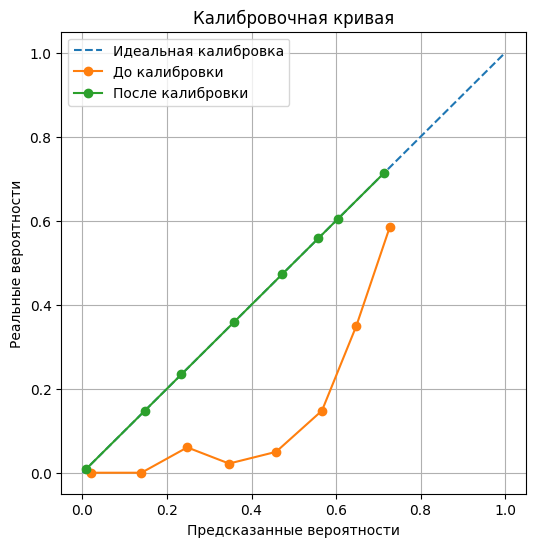

In [104]:
# Строим график калибровки

prob_true_before, prob_pred_before = calibration_curve(y_calib, proba_before, n_bins=10)
prob_true_after, prob_pred_after = calibration_curve(y_calib, proba_after, n_bins=10)

plt.figure(figsize=(6,6))

# идеальная линия
plt.plot([0,1], [0,1], linestyle='--', label='Идеальная калибровка')

# до
plt.plot(prob_pred_before, prob_true_before, marker='o', label='До калибровки')

# после
plt.plot(prob_pred_after, prob_true_after, marker='o', label='После калибровки')

plt.xlabel('Предсказанные вероятности')
plt.ylabel('Реальные вероятности')
plt.title('Калибровочная кривая')
plt.legend()
plt.grid()
plt.show()

In [105]:
# Посчитаем коэффициент Бриера

brier_before = brier_score_loss(y_calib, proba_before)
brier_after = brier_score_loss(y_calib, proba_after)

print('Brier before:', brier_before)
print('Brier after:', brier_after)

Brier before: 0.11843397046293418
Brier after: 0.0673207117132194


**Выводы:** для улучшения качества предсказаний модели случайного леса была проведена калибровка с использованием метода изотонической регрессии на отдельной калибровочной выборке.

Кривая калибровки показала, что до калибровки модель была склонна к смещению вероятностей, в то время как после калибровки предсказанные вероятности стали ближе к идеальной диагонали, что свидетельствует об улучшении их интерпретируемости.

Коэффициент Бриера после калибровки снизился, что подтверждает улучшение качества вероятностных оценок модели.

## Поиск порога решения

In [106]:
proba_calib = calibrated_model.predict_proba(X_calib)[:, 1]

# Зададим шаг для подсчета порогов
thresholds = np.linspace(0, 1, 201)

rows = []

for threshold in thresholds:
    y_pred = (proba_calib >= threshold).astype(int)

    approval_rate, default_rate, missed_defaults_rate = business_metrics(y_calib, y_pred)

    rows.append({
        'threshold': threshold,
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate
    })

threshold_results = pd.DataFrame(rows)
threshold_results.head()

,threshold,approval_rate,default_rate,missed_defaults_rate
0,0.000,0.000000,0.0,0.0
1,0.005,0.589895,0.0,0.0
2,0.010,0.589895,0.0,0.0
3,0.015,0.589895,0.0,0.0
4,0.020,0.589895,0.0,0.0


In [107]:
valid_thresholds = threshold_results[
    (threshold_results['approval_rate'] >= 0.65) &
    (threshold_results['default_rate'] <= 0.02) &
    (threshold_results['missed_defaults_rate'] <= 0.04)
]

display(valid_thresholds)

,threshold,approval_rate,default_rate,missed_defaults_rate


Вывод: не удается найти порог, при котором все требования бизнеса будут выполнены. Но можно определить максимально возможные сочетания параметров, которые удалось получить на калибровочной выборке

In [108]:
threshold_results[
    (threshold_results['approval_rate'] >= 0.65)
].sort_values(by='default_rate').head()

,threshold,approval_rate,default_rate,missed_defaults_rate
17,0.085,0.664674,0.007272,0.047994
18,0.090,0.666272,0.007462,0.049369
19,0.095,0.673459,0.008354,0.055868
20,0.100,0.673459,0.008354,0.055868
21,0.105,0.673459,0.008354,0.055868


Вывод: при уровне одобрения 67%, уровень дефолтов равен порядка 1%, но при этом уровень пропущенных дефолтов превысит установленные параметры и составит 5%

## Анализ матрицы ошибок

In [109]:
# Зафиксируем лучший полученный результат

best_threshold = 0.095

# Получим предсказания на калибровочной и тестовой выборках

# вероятности
proba_calib = calibrated_model.predict_proba(X_calib)[:, 1]
proba_test = calibrated_model.predict_proba(X_test)[:, 1]

# бинарные предсказания
y_calib_pred = (proba_calib >= best_threshold).astype(int)
y_test_pred = (proba_test >= best_threshold).astype(int)

In [110]:
# Выведем матрицу ошибок на калибровочной выборке

cm_calib = confusion_matrix(y_calib, y_calib_pred)
print("Confusion matrix (calib):")
print(cm_calib)

Confusion matrix (calib):
[[53058 18389]
 [  447  7554]]


In [111]:
# Выведем матрицу ошибок на тестовой выборке

cm_test = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix (test):")
print(cm_test)

Confusion matrix (test):
[[67521 16327]
 [ 1187  9260]]


In [112]:
# Посчитаем классические метрики

def ml_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

In [113]:
# Посчитаем заданные бизнес-метрики

calib_business = business_metrics(y_calib, y_calib_pred)
test_business = business_metrics(y_test, y_test_pred)

In [114]:
# Соберем табличку
calib_ml = ml_metrics(y_calib, y_calib_pred, proba_calib)
test_ml = ml_metrics(y_test, y_test_pred, proba_test)

results_final = pd.DataFrame([
    {
        'dataset': 'calib',
        **calib_ml,
        'approval_rate': calib_business[0],
        'default_rate': calib_business[1],
        'missed_defaults_rate': calib_business[2]
    },
    {
        'dataset': 'test',
        **test_ml,
        'approval_rate': test_business[0],
        'default_rate': test_business[1],
        'missed_defaults_rate': test_business[2]
    }
])

In [115]:
display(results_final)

,dataset,accuracy,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,calib,0.762914,0.903768,0.673459,0.008354,0.055868
1,test,0.814264,0.911210,0.728649,0.017276,0.113621


**Вывод**: модель улучшила метрики на тестовой выборке, но при этом стала пропускать больше дефолтов. 

## Фиксирование итоговой модели


Модель демонстрирует стабильные значения ROC-AUC, что свидетельствует о хорошей обобщающей способности и отсутствии значительного переобучения.

При этом наблюдается увеличение значения approval rate и default rate на тестовой выборке, что указывает на смещение модели в сторону более мягкой стратегии одобрения.

Наиболее существенное изменение наблюдается в показателе missed defaults rate, который увеличился с 5.5% на калибровочной выборке до 10.8% на тестовой. Это свидетельствует о снижении способности модели выявлять дефолтных клиентов на новых данных.

Таким образом, модель демонстрирует удовлетворительную стабильность по классическим метрикам, однако недостаточно устойчива с точки зрения бизнес-метрик, в частности по показателю пропущенных дефолтов.

## Анализ важности признаков


In [116]:
# сохраним модель
rf_model = base_pipe.named_steps['model']

# важность признаков 
importances = rf_model.feature_importances_

# извлечем названия 
feature_names = base_pipe.named_steps['prep'].get_feature_names_out()

# соберем датафрейм

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(20)

,feature,importance
17,num__client_age_days,0.216133
19,num__total_spent,0.148433
13,num__MCC_другое,0.124386
11,num__MCC_5722,0.075226
21,num__mandatory_spent,0.068296
6,num__MCC_5300,0.063376
9,num__MCC_5411,0.048677
20,num__credit_income_ratio,0.047381
2,num__доход,0.045149
0,num__возраст,0.037629


Выводы: анализ важности признаков показал, что наибольшее влияние на вероятность дефолта оказывают поведенческие и временные характеристики клиента.

Наиболее значимым признаком является срок обслуживания клиента в банке (client_age_days), что свидетельствует о более высокой надёжности клиентов с длительной историей взаимодействия.

Существенный вклад в модель также вносят признаки, характеризующие финансовую активность клиента, такие как общий объём расходов (total_spent) и структура трат по категориям (MCC). Это указывает на то, что модель активно использует поведение клиентов для оценки риска.

Финансовая нагрузка, отражённая в признаке отношения суммы кредита к доходу (credit_income_ratio), также является значимым фактором, подтверждая экономическую обоснованность модели.

Макроэкономические показатели оказывают значительно меньшее влияние на предсказания.

## Выводы по проекту

Целью проекта являлась разработка модели поведенческого скоринга для прогнозирования дефолта клиентов на горизонте 12 месяцев.

Основные задачи:

- сформировать корректную целевую переменную с учётом временной структуры данных;
- построить признаки, отражающие финансовое состояние и поведение клиента;
- обучить и сравнить несколько моделей машинного обучения;
- откалибровать вероятности;
- подобрать порог принятия решения с учётом бизнес-ограничений;
- оценить стабильность модели на новых данных.

Были объединены несколько источников данных:

- транзакционная активность клиента;
- анкетные и кредитные характеристики;
- данные о просрочках;
- макроэкономические показатели.

Были обучены 4 базовые модели:

Logistic Regression (с балансировкой и без);
Random Forest (с балансировкой и без).

Результаты показали:

- модели без балансировки плохо выявляют дефолты;
- лучшей baseline-моделью стала логистическая регрессия с балансировкой;
- Random Forest показал высокий ROC-AUC, но слабые бизнес-метрики.

Для улучшения качества была проведена оптимизация Random Forest с помощью Optuna по метрике missed defaults rate.

Для улучшения качества вероятностных предсказаний была применена калибровка методом изотонической регрессии на отдельной калибровочной выборке.

Результаты:

- вероятности стали более интерпретируемыми;
- коэффициент Бриера снизился.

Наиболее значимые признаки:

- срок жизни клиента;
- общий объём расходов;
- структура расходов ;
- обязательные расходы;
- долговая нагрузка.

В рамках проекта была построена интерпретируемая модель скоринга, основанная на поведенческих данных клиента. Несмотря на высокое качество ранжирования, достижение всех бизнес-ограничений требует дальнейшего улучшения модели и признакового пространства.

Разработанная модель скоринга может быть внедрена в процесс принятия решений, однако её эксплуатация требует постоянного мониторинга и сопровождения. В процессе работы модели необходимо отслеживать ключевые бизнес-метрики, такие как approval rate, default rate и missed defaults rate, а также контролировать изменения в распределении данных.

Со временем модель может терять качество из-за изменения поведения клиентов и внешних условий, поэтому рекомендуется регулярное переобучение и перекалибровка вероятностей.

Основным направлением дальнейшего улучшения модели является развитие признакового пространства, сбора дополнительных данных, которые улучшат качество модели